
## **Data Loading and Preprocessing**

In [ ]:
install.packages("BiocManager")
BiocManager::install("DESeq2")
BiocManager::install("EnhancedVolcano")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.3 (2026-03-11)

Installing package(s) 'BiocVersion', 'DESeq2'

also installing the dependencies ‘XVector’, ‘formatR’, ‘abind’, ‘SparseArray’, ‘lambda.r’, ‘futile.options’, ‘Seqinfo’, ‘S4Arrays’, ‘DelayedArray’, ‘futile.logger’, ‘snow’, ‘BH’, ‘S4Vectors’, ‘IRanges’, ‘GenomicRanges’, ‘SummarizedExperiment’, ‘BiocGenerics’, ‘Biobase’, ‘BiocParallel’, ‘matrixStats’, ‘locfit’, ‘MatrixGenerics’, ‘RcppArmadillo’


Old packages: 'backports', 'bit64', 'cli', 'cpp11', 'curl', 'devtools',
  'dplyr', 'ellipsis', 'fs', 'ggplot2', 'glue', 'magrittr', 'nlme', 'openssl',
  'pak', 'pkgload', 'processx', 'ps', 'purrr', 'Rcpp', 'rlang', 'S7', 'vctrs',
  'vroom', 'xtable'

'getOpt

In [ ]:
### Load Libraries
library("DESeq2")
library("EnhancedVolcano")

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

In [16]:
##Load data
data = read.table('/content/GBM Cancer.txt', header = TRUE, row.names = 1, sep='\t')

In [17]:
head(data)

,VU284_GBM_vIII,VU306_GBM_vIII,VU360_GBM_WT,VU372_GBM_vIII,VU378_GBM,VU393_GBM_vIII,VU394Platelet_hiseq,VU402_2_GBM,VU406_2_GBM,VU408_GBM,⋯,GBM_505,Control_2,Control_3,Control_4,Control_5,Control_6,Control_8,Control_9,Control_10,Control_13
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
ENSG00000000003,4,0,0,0,7,0,0,0,4,0,⋯,0,0,0,0,0,0,1,3,0,0
ENSG00000000419,0,0,0,0,50,0,0,21,22,31,⋯,0,0,75,0,17,139,0,100,94,190
ENSG00000000457,0,0,0,0,5,14,0,0,0,23,⋯,0,17,23,0,0,0,52,17,0,12
ENSG00000000460,13,21,1,9,18,6,6,7,5,11,⋯,11,4,6,4,10,1,25,21,0,27
ENSG00000000938,20,0,0,36,76,12,392,45,5,109,⋯,9,196,32,36,94,319,123,132,72,337
ENSG00000000971,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,56,0,0,0,0


In [18]:
dim(data)

[1] 17747    44

In [19]:
# Save the sample name into an object
names_pdx <- colnames(data)

In [9]:
names_pdx

[1] "VU284_GBM_vIII"      "VU306_GBM_vIII"      "VU360_GBM_WT"       
 [4] "VU372_GBM_vIII"      "VU378_GBM"           "VU393_GBM_vIII"     
 [7] "VU394Platelet_hiseq" "VU402_2_GBM"         "VU406_2_GBM"        
[10] "VU408_GBM"           "VU417_GBM_vIII"      "VU421_GBM"          
[13] "VU422_GBM"           "VU425_GBM"           "VU429_1_GBM_vIII"   
[16] "VU430_GBM"           "VU431_1_GBM_vIII"    "VU436_1_GBM_vIII"   
[19] "GBM_438"             "VU439_1_GBM_vIII"    "GBM_440"            
[22] "VU443_1_GBM_WT"      "VU445_1_GBM_WT"      "VU454_1_GBM_WT"     
[25] "VU456_1_GBM_WT"      "VU468_1_GBM_WT"      "GBM_471"            
[28] "GBM_475"             "GBM_476"             "GBM_480"            
[31] "GBM_484"             "GBM_485"             "GBM_486"            
[34] "GBM_499"             "GBM_505"             "Control_2"          
[37] "Control_3"           "Control_4"           "Control_5"          
[40] "Control_6"           "Control_8"           "Control_9"          
[43] "Control_10"          "Control_13"

In [20]:
# Create sample annotation corresponding to their phenotypical condition or biological state
meta_classes <- c(rep("GBM_Cancer",35), rep("Control",9))

In [21]:
meta_classes

[1] "GBM_Cancer" "GBM_Cancer" "GBM_Cancer" "GBM_Cancer" "GBM_Cancer"
 [6] "GBM_Cancer" "GBM_Cancer" "GBM_Cancer" "GBM_Cancer" "GBM_Cancer"
[11] "GBM_Cancer" "GBM_Cancer" "GBM_Cancer" "GBM_Cancer" "GBM_Cancer"
[16] "GBM_Cancer" "GBM_Cancer" "GBM_Cancer" "GBM_Cancer" "GBM_Cancer"
[21] "GBM_Cancer" "GBM_Cancer" "GBM_Cancer" "GBM_Cancer" "GBM_Cancer"
[26] "GBM_Cancer" "GBM_Cancer" "GBM_Cancer" "GBM_Cancer" "GBM_Cancer"
[31] "GBM_Cancer" "GBM_Cancer" "GBM_Cancer" "GBM_Cancer" "GBM_Cancer"
[36] "Control"    "Control"    "Control"    "Control"    "Control"   
[41] "Control"    "Control"    "Control"    "Control"

In [22]:
# Combine both to a dataframe
meta_data <- data.frame(names_pdx, meta_classes)

# Display the dataframe for verification
meta_data

names_pdx,meta_classes
<chr>,<chr>
VU284_GBM_vIII,GBM_Cancer
VU306_GBM_vIII,GBM_Cancer
VU360_GBM_WT,GBM_Cancer
VU372_GBM_vIII,GBM_Cancer
VU378_GBM,GBM_Cancer
VU393_GBM_vIII,GBM_Cancer
VU394Platelet_hiseq,GBM_Cancer
VU402_2_GBM,GBM_Cancer
VU406_2_GBM,GBM_Cancer


In [23]:
# Assign Control as the reference level (control group) in the meta_data
meta_data$meta_classes <- relevel(factor(meta_data$meta_classes), ref = "Control")

## **DESeq2 Analysis**

In [24]:
ds <- DESeqDataSetFromMatrix(countData = round(data,0),
                             colData = meta_data,
                             design = ~meta_classes)

converting counts to integer mode



In [25]:
ds

class: DESeqDataSet 
dim: 17747 44 
metadata(1): version
assays(1): counts
rownames(17747): ENSG00000000003 ENSG00000000419 ... ENSG00000273486
  ENSG00000273492
rowData names(0):
colnames(44): VU284_GBM_vIII VU306_GBM_vIII ... Control_10 Control_13
colData names(2): names_pdx meta_classes

In [26]:
# Run Deseq analysis
DS_run <- DESeq(ds)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 613 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [27]:
DS_run

class: DESeqDataSet 
dim: 17747 44 
metadata(1): version
assays(6): counts mu ... replaceCounts replaceCooks
rownames(17747): ENSG00000000003 ENSG00000000419 ... ENSG00000273486
  ENSG00000273492
rowData names(23): baseMean baseVar ... maxCooks replace
colnames(44): VU284_GBM_vIII VU306_GBM_vIII ... Control_10 Control_13
colData names(4): names_pdx meta_classes sizeFactor replaceable

In [28]:
# Store the results of the analysis
res <- results(DS_run)
# Print out the results
print(res)

log2 fold change (MLE): meta classes GBM Cancer vs Control 
Wald test p-value: meta classes GBM Cancer vs Control 
DataFrame with 17747 rows and 6 columns
                 baseMean log2FoldChange     lfcSE       stat    pvalue
                <numeric>      <numeric> <numeric>  <numeric> <numeric>
ENSG00000000003   1.09252      2.2758661  1.369485  1.6618403 0.0965448
ENSG00000000419  25.79350     -0.8013320  0.826330 -0.9697487 0.3321718
ENSG00000000457   7.31255     -0.0766147  0.980619 -0.0781289 0.9377255
ENSG00000000460  12.46052      1.1530641  0.538420  2.1415685 0.0322282
ENSG00000000938  91.84938      0.0776877  0.656140  0.1184011 0.9057498
...                   ...            ...       ...        ...       ...
ENSG00000273437 0.1694772       1.311578   2.85319  0.4596884  0.645740
ENSG00000273445 0.1422301      -0.293599   2.98476 -0.0983661  0.921642
ENSG00000273456 0.0779229       0.640049   3.65688  0.1750262  0.861059
ENSG00000273486 0.2400064       1.007450   1.60161  0

In [29]:
# Filter genes with low expression values
ds_filt <- ds[ rowSums(counts(ds)) > 5, ]
# Print the summary of the new DESeq object
ds_filt

class: DESeqDataSet 
dim: 14805 44 
metadata(1): version
assays(1): counts
rownames(14805): ENSG00000000003 ENSG00000000419 ... ENSG00000273445
  ENSG00000273486
rowData names(0):
colnames(44): VU284_GBM_vIII VU306_GBM_vIII ... Control_10 Control_13
colData names(2): names_pdx meta_classes

In [30]:
# Run Deseq2 Analysis
DS_run <- DESeq(ds_filt)
# Store the results of the analysis
res <- results(DS_run)
# Print the results
print(res)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 613 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



log2 fold change (MLE): meta classes GBM Cancer vs Control 
Wald test p-value: meta classes GBM Cancer vs Control 
DataFrame with 14805 rows and 6 columns
                 baseMean log2FoldChange     lfcSE       stat    pvalue
                <numeric>      <numeric> <numeric>  <numeric> <numeric>
ENSG00000000003   1.09252      2.2759528  1.373237  1.6573634 0.0974460
ENSG00000000419  25.79350     -0.8013335  0.826574 -0.9694632 0.3323141
ENSG00000000457   7.31255     -0.0766154  0.982020 -0.0780181 0.9378136
ENSG00000000460  12.46052      1.1530673  0.538315  2.1419918 0.0321941
ENSG00000000938  91.84938      0.0776886  0.655842  0.1184564 0.9057061
...                   ...            ...       ...        ...       ...
ENSG00000273356  0.429661       1.952676   1.29348   1.509625  0.131139
ENSG00000273388  0.113302      -1.198352   3.63756  -0.329439  0.741824
ENSG00000273437  0.169477       1.311609   2.87751   0.455814  0.648524
ENSG00000273445  0.142230      -0.293446   3.00946  -

In [31]:
# Sort in ascending order of statistical significance
res[order(res$padj),]

log2 fold change (MLE): meta classes GBM Cancer vs Control 
Wald test p-value: meta classes GBM Cancer vs Control 
DataFrame with 14805 rows and 6 columns
                 baseMean log2FoldChange     lfcSE      stat      pvalue
                <numeric>      <numeric> <numeric> <numeric>   <numeric>
ENSG00000156642   668.124        3.41581  0.199755   17.1000 1.48437e-65
ENSG00000112308  1948.306        2.60278  0.181500   14.3404 1.22400e-46
ENSG00000142875   579.992        3.36779  0.234511   14.3609 9.10461e-47
ENSG00000164181  1054.333        2.64420  0.196149   13.4806 2.03498e-41
ENSG00000152601  3082.627        2.32200  0.174044   13.3415 1.32808e-40
...                   ...            ...       ...       ...         ...
ENSG00000273356  0.429661       1.952676   1.29348  1.509625    0.131139
ENSG00000273388  0.113302      -1.198352   3.63756 -0.329439    0.741824
ENSG00000273437  0.169477       1.311609   2.87751  0.455814    0.648524
ENSG00000273445  0.142230      -0.293446  

In [ ]:
# total number of genes that are statistically siginicant
sum(res$padj < 0.05, na.rm = TRUE)

[1] 1148

## **Visualization and Annotation**

Warning message in plot.window(...):
“"Main" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"Main" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"Main" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"Main" is not a graphical parameter”
Warning message in box(...):
“"Main" is not a graphical parameter”
Warning message in title(...):
“"Main" is not a graphical parameter”


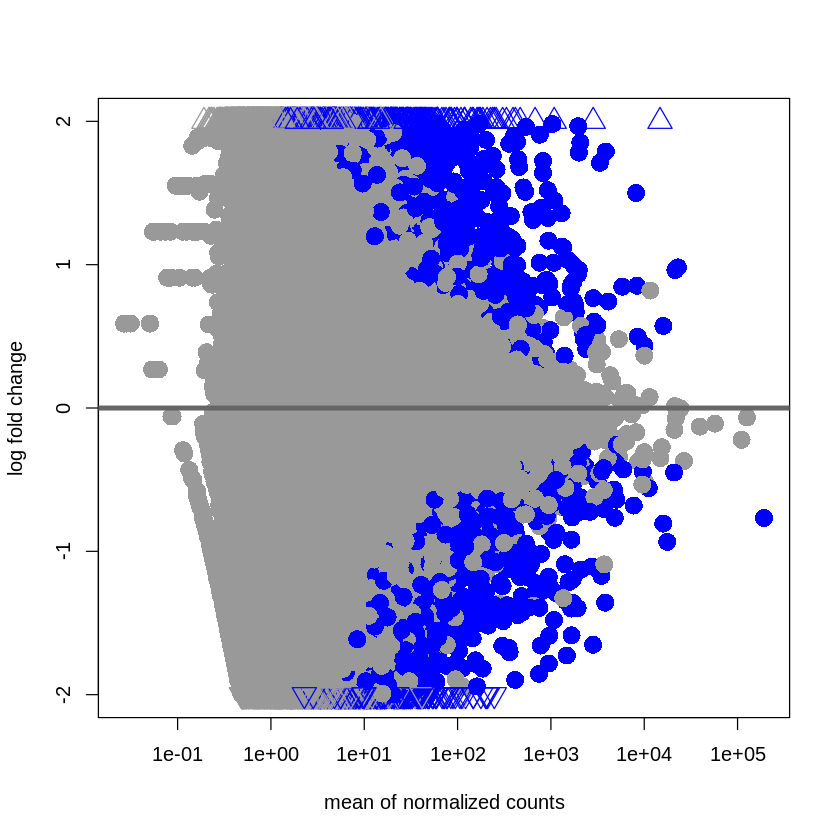

In [ ]:
plotMA(res, Main = "DESeq2", ylim = c(-2,2), cex = 2)

In [32]:
summary(res$log2FoldChange)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-3.7450 -0.2540  0.6589  0.8228  1.6802 10.6247 

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”


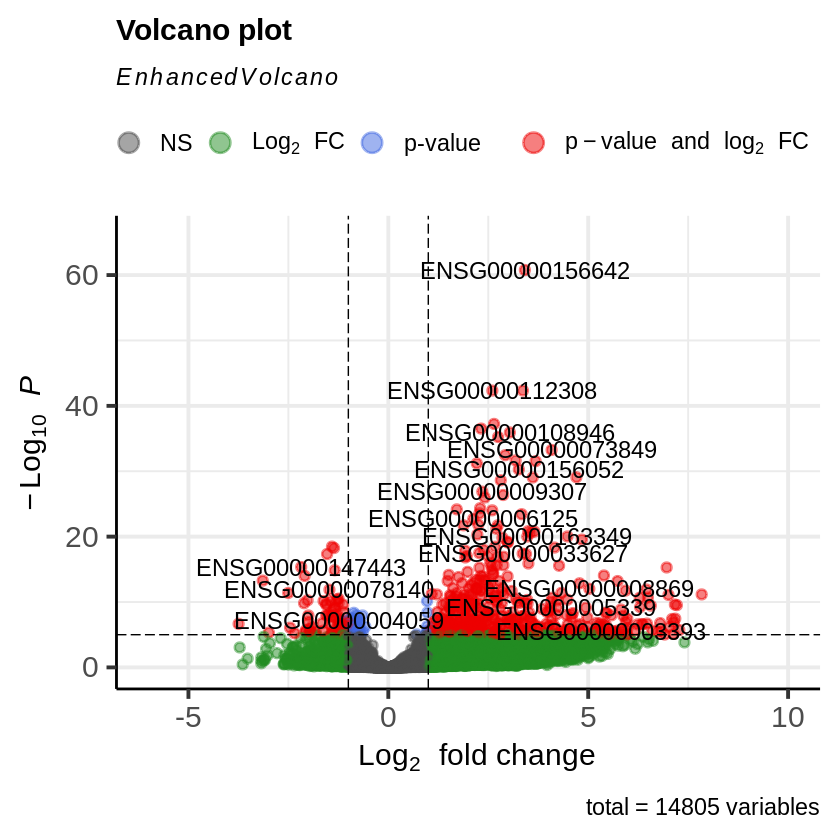

In [33]:
EnhancedVolcano(res,
                x = 'log2FoldChange',
                y = 'padj',
                lab = rownames(res),
                xlim = c(-6,10))

In [34]:
write.table(res,"DESeq2_Result.txt", row.names=TRUE,col.names=TRUE, sep="\t", quote=TRUE, append=TRUE)

Warning message in write.table(res, "DESeq2_Result.txt", row.names = TRUE, col.names = TRUE, :
“appending column names to file”


In [35]:
res

log2 fold change (MLE): meta classes GBM Cancer vs Control 
Wald test p-value: meta classes GBM Cancer vs Control 
DataFrame with 14805 rows and 6 columns
                 baseMean log2FoldChange     lfcSE       stat    pvalue
                <numeric>      <numeric> <numeric>  <numeric> <numeric>
ENSG00000000003   1.09252      2.2759528  1.373237  1.6573634 0.0974460
ENSG00000000419  25.79350     -0.8013335  0.826574 -0.9694632 0.3323141
ENSG00000000457   7.31255     -0.0766154  0.982020 -0.0780181 0.9378136
ENSG00000000460  12.46052      1.1530673  0.538315  2.1419918 0.0321941
ENSG00000000938  91.84938      0.0776886  0.655842  0.1184564 0.9057061
...                   ...            ...       ...        ...       ...
ENSG00000273356  0.429661       1.952676   1.29348   1.509625  0.131139
ENSG00000273388  0.113302      -1.198352   3.63756  -0.329439  0.741824
ENSG00000273437  0.169477       1.311609   2.87751   0.455814  0.648524
ENSG00000273445  0.142230      -0.293446   3.00946  -

In [36]:
# Install and load required packages
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

In [37]:
BiocManager::install("org.Hs.eg.db")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.3 (2026-03-11)

Installing package(s) 'org.Hs.eg.db'

also installing the dependencies ‘png’, ‘Biostrings’, ‘RSQLite’, ‘KEGGREST’, ‘AnnotationDbi’


Old packages: 'backports', 'bit64', 'cli', 'cpp11', 'curl', 'devtools',
  'dplyr', 'ellipsis', 'fs', 'ggplot2', 'glue', 'magrittr', 'nlme', 'openssl',
  'pak', 'pkgload', 'processx', 'ps', 'purrr', 'Rcpp', 'rlang', 'S7', 'vctrs',
  'vroom', 'xtable'



In [38]:
library(org.Hs.eg.db)

Loading required package: AnnotationDbi





In [39]:
BiocManager::install("AnnotationDbi")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.3 (2026-03-11)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'AnnotationDbi'”
Old packages: 'backports', 'bit64', 'cli', 'cpp11', 'curl', 'devtools',
  'dplyr', 'ellipsis', 'fs', 'ggplot2', 'glue', 'magrittr', 'nlme', 'openssl',
  'pak', 'pkgload', 'processx', 'ps', 'purrr', 'Rcpp', 'rlang', 'S7', 'vctrs',
  'vroom', 'xtable'



In [40]:
library(AnnotationDbi)

In [41]:
# Filter the DESeq results based on fold change and adjusted p-value
filtered_res <- res[which(res$padj < 0.05 & abs(res$log2FoldChange) > 1), ]

# Get Ensembl IDs from row names of filtered_res
ensembl_ids <- rownames(filtered_res)

# Convert Ensembl IDs to gene symbols using org.Hs.eg.db
gene_symbols <- mapIds(org.Hs.eg.db,
                       keys = ensembl_ids,
                       column = "SYMBOL",
                       keytype = "ENSEMBL",
                       multiVals = "first")

# Remove missing values in gene_symbols
gene_symbols <- gene_symbols[!is.na(gene_symbols)]

# Subset filtered_res to include only genes with valid symbols
filtered_res <- filtered_res[names(gene_symbols), ]

# Replace Ensembl IDs with gene symbols in filtered_res
rownames(filtered_res) <- gene_symbols

'select()' returned 1:many mapping between keys and columns



In [42]:
# Create a new column in 'res' and fill with NAs
res$gene_symbol <- NA

# Replace NAs with corresponding gene symbols where available
res$gene_symbol[match(names(gene_symbols), rownames(res))] <- gene_symbols

# Save the DESeq results with gene symbols
write.table(res, "DESeq2_Result_with_gene_symbols.txt", row.names = TRUE, col.names = TRUE, sep = "\t", quote = TRUE, append = TRUE)

Warning message in write.table(res, "DESeq2_Result_with_gene_symbols.txt", row.names = TRUE, :
“appending column names to file”


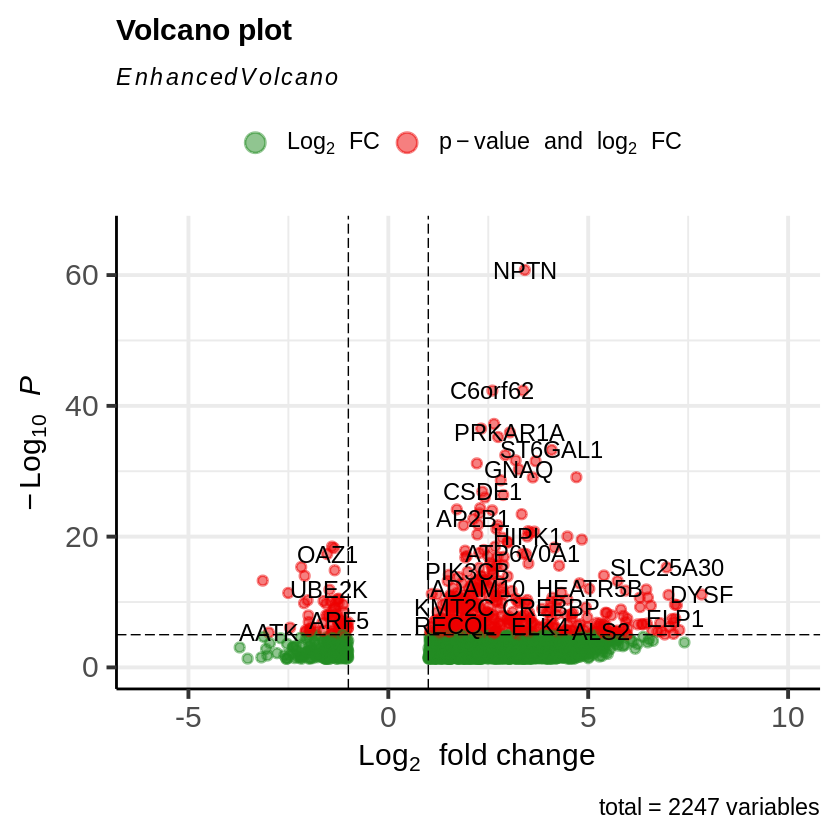

In [43]:
# Create the volcano plot with gene symbols
EnhancedVolcano(filtered_res,
                lab = rownames(filtered_res),
                x = 'log2FoldChange',
                y = 'padj',
                xlim = c(-6, 10))

## **Heatmap Visualization**

In [44]:
install.packages("pheatmap")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [45]:
library(pheatmap)

In [46]:
# Load the DESeq2 results from your DESeq2 analysis
# Ensure 'res' is the result from DESeq2 containing log2FoldChange and padj

# Extract the top 10 upregulated and top 10 downregulated genes
# Assuming 'res' is your DESeq2 result object, filter based on log2FoldChange and padj
top_upregulated <- res[order(res$log2FoldChange, decreasing = TRUE), ][1:10, ]
top_downregulated <- res[order(res$log2FoldChange, decreasing = FALSE), ][1:10, ]

# Combine top upregulated and downregulated genes
top_genes <- rbind(top_upregulated, top_downregulated)

# Get the gene names
top_gene_names <- rownames(top_genes)

# Extract expression data for the top genes from your dataset
# Assuming 'data' is your expression matrix from the image you provided
top_genes_expr <- data[top_gene_names, ]

In [47]:
# Now, create custom sample names based on your dataset's colnames
# Extract original column names
original_colnames <- colnames(data)

In [48]:
# Create custom names based on the dataset's colnames
custom_sample_names <- ifelse(grepl("Control", original_colnames),
                              paste0("Control_", seq_along(grep("Control", original_colnames))),
                              paste0("Tumor_", seq_along(grep("Tumor", original_colnames))))

In [49]:
# Assign the new custom names to the colnames of your expression matrix
colnames(data) <- custom_sample_names

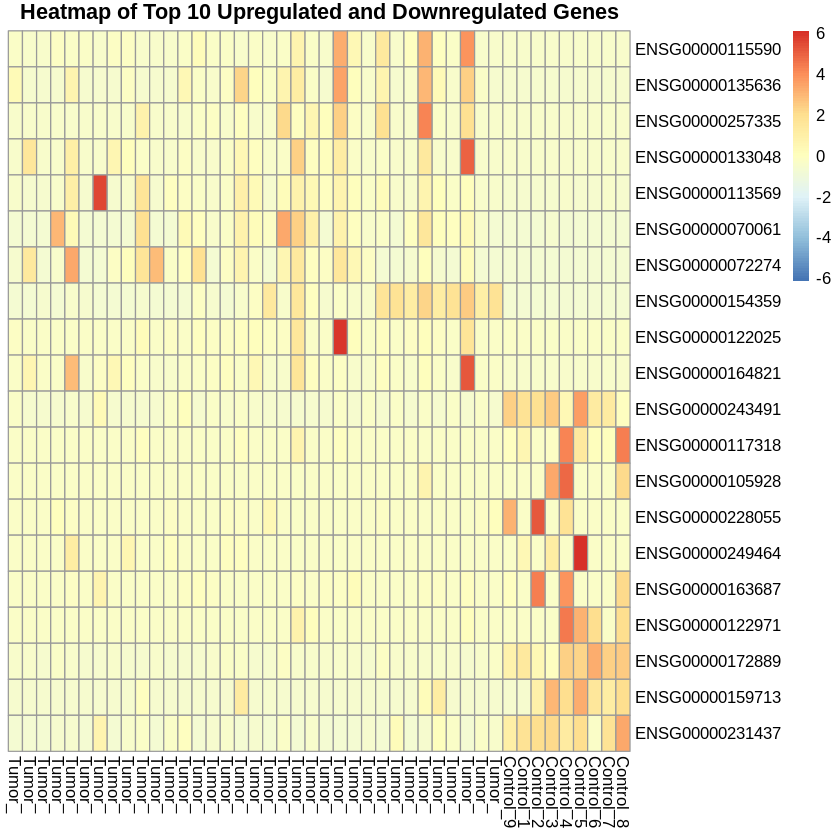

In [50]:
# Create the heatmap using pheatmap with custom sample names
library(pheatmap)
pheatmap(top_genes_expr,
         scale = "row",              # Scale rows to center gene expression
         cluster_cols = FALSE,       # Disable column clustering (no dendrogram)
         cluster_rows = FALSE,       # Disable row clustering (no dendrogram)
         show_rownames = TRUE,       # Show gene names on y-axis
         show_colnames = TRUE,       # Show custom sample names on x-axis
         main = "Heatmap of Top 10 Upregulated and Downregulated Genes",
         labels_col = colnames(data))  # Use the modified colnames

'select()' returned 1:many mapping between keys and columns



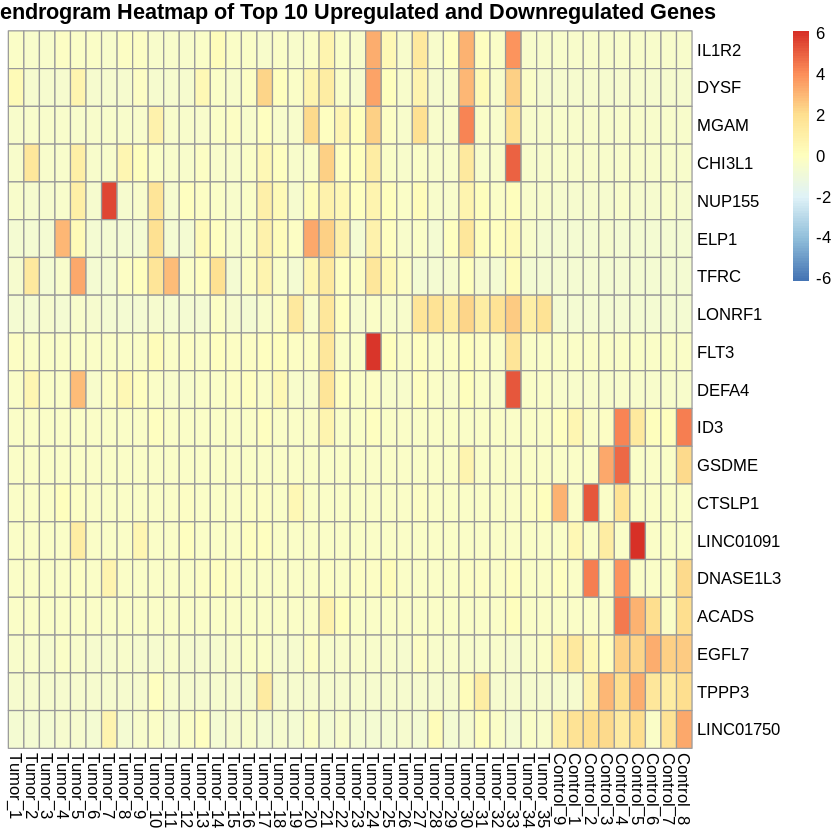

In [51]:
# Extract the top 10 upregulated and top 10 downregulated genes
top_upregulated <- res[order(res$log2FoldChange, decreasing = TRUE), ][1:10, ]
top_downregulated <- res[order(res$log2FoldChange, decreasing = FALSE), ][1:10, ]

# Combine top upregulated and downregulated genes
top_genes <- rbind(top_upregulated, top_downregulated)

# Get the Ensembl IDs of the top genes
top_gene_ensembl_ids <- rownames(top_genes)

# Convert Ensembl IDs to gene symbols
top_gene_symbols <- mapIds(org.Hs.eg.db,
                            keys = top_gene_ensembl_ids,
                            column = "SYMBOL",
                            keytype = "ENSEMBL",
                            multiVals = "first")

# Remove any NA values (genes without symbols)
top_gene_symbols <- top_gene_symbols[!is.na(top_gene_symbols)]

# Subset the expression data for the top genes
top_genes_expr <- data[names(top_gene_symbols), ]

# Create custom sample names
original_colnames <- colnames(data)
custom_sample_names <- ifelse(grepl("Control", original_colnames),
                              paste0("Control_", seq_along(grep("Control", original_colnames))),
                              paste0("Tumor_", seq_along(grep("Tumor", original_colnames))))
colnames(top_genes_expr) <- custom_sample_names # Assign custom names


# Create the heatmap with gene symbols on the x-axis
pheatmap(top_genes_expr,
         scale = "row",
         cluster_cols = FALSE,
         cluster_rows = FALSE,
         show_rownames = TRUE,
         show_colnames = TRUE,
         main = "Dendrogram Heatmap of Top 10 Upregulated and Downregulated Genes",
         labels_col = custom_sample_names, # Custom sample names for columns
         labels_row = top_gene_symbols)   # Gene symbols for rows

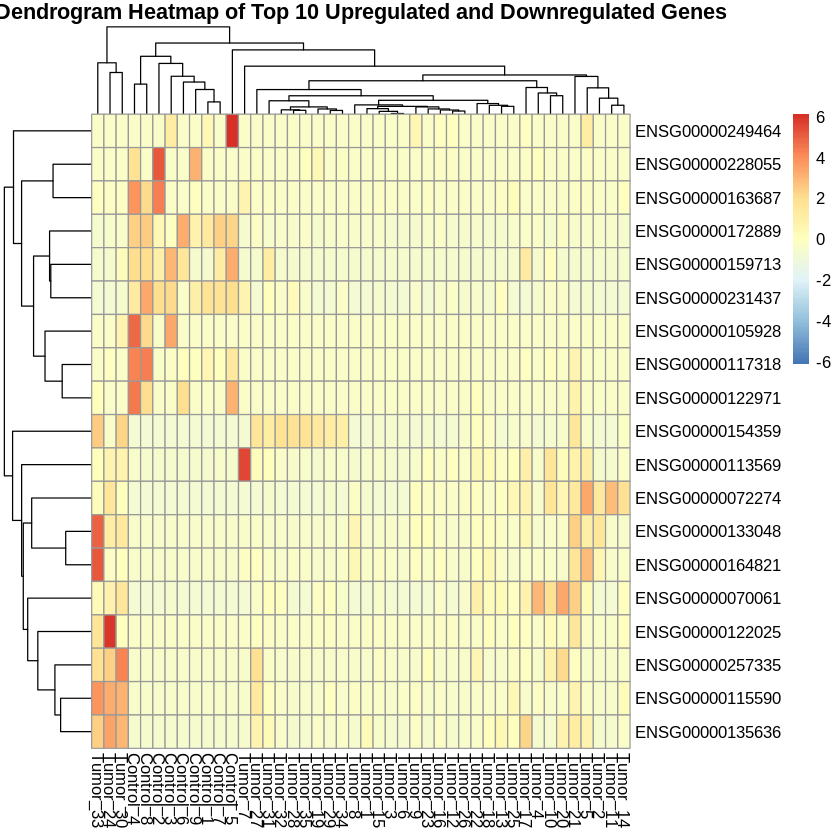

In [52]:
library(pheatmap)
pheatmap(top_genes_expr,
         scale = "row",              # Scale rows to center gene expression
         cluster_cols = TRUE,        # Enable column clustering (dendrogram)
         cluster_rows = TRUE,        # Enable row clustering (dendrogram)
         show_rownames = TRUE,       # Show gene symbols on y-axis
         show_colnames = TRUE,       # Show custom sample names on x-axis
         main = "Dendrogram Heatmap of Top 10 Upregulated and Downregulated Genes",
         labels_col = custom_sample_names)  # Use custom sample names for x-axis

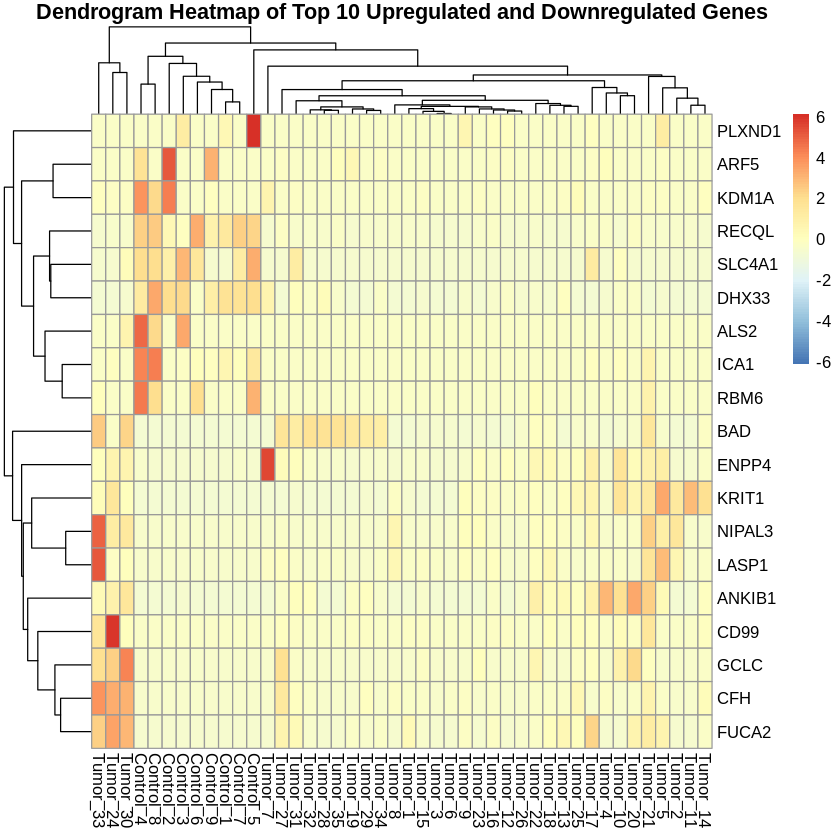

In [53]:
library(pheatmap)
pheatmap(top_genes_expr,
         scale = "row",              # Scale rows to center gene expression
         cluster_cols = TRUE,        # Enable column clustering (dendrogram)
         cluster_rows = TRUE,        # Enable row clustering (dendrogram)
         show_rownames = TRUE,       # Show gene symbols on y-axis
         show_colnames = TRUE,       # Show custom sample names on x-axis
         main = "Dendrogram Heatmap of Top 10 Upregulated and Downregulated Genes",
         labels_col = custom_sample_names,
         labels_row = gene_symbols)  # Use custom sample names for x-axis

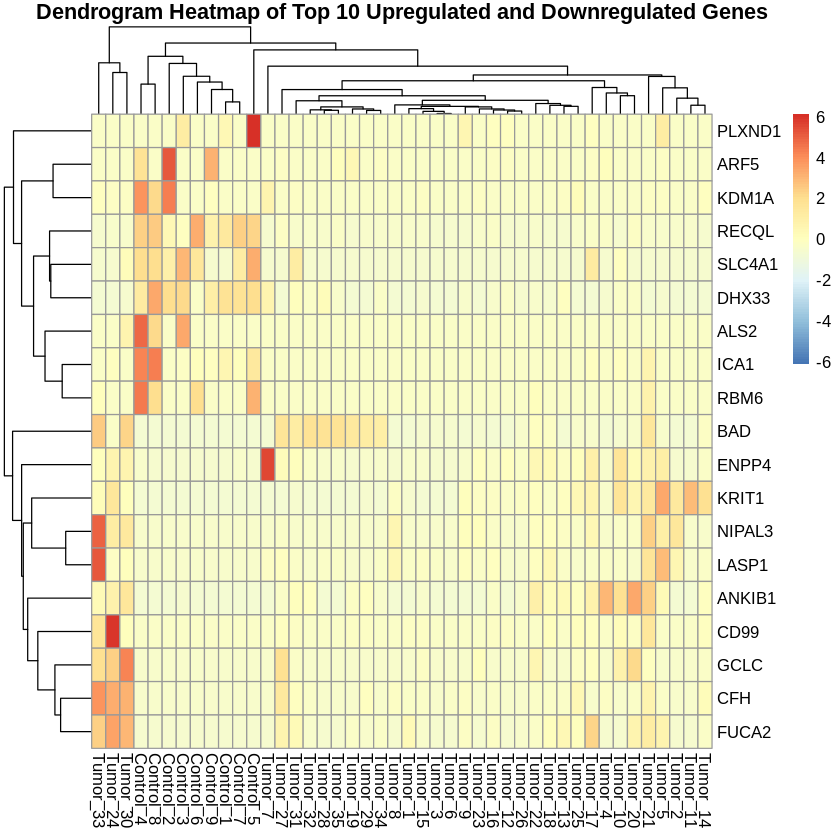

In [54]:
library(pheatmap)

# Store the heatmap as an object
Dendrogram_Heatmap <- pheatmap(top_genes_expr,
                     scale = "row",              # Scale rows to center gene expression
                     cluster_cols = TRUE,        # Enable column clustering (dendrogram)
                     cluster_rows = TRUE,        # Enable row clustering (dendrogram)
                     show_rownames = TRUE,       # Show gene symbols on y-axis
                     show_colnames = TRUE,       # Show custom sample names on x-axis
                     main = "Dendrogram Heatmap of Top 10 Upregulated and Downregulated Genes",
                     labels_col = custom_sample_names,
                     labels_row = gene_symbols)


In [55]:
install.packages("gridExtra")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [56]:
# Load the gridExtra package for saving
library(gridExtra)

# Save the heatmap object as a PNG file
png("/content/Dendrogram_Heatmap.png", width = 10, height = 10, units = "in", res = 300)
grid::grid.draw(Dendrogram_Heatmap$gtable)
dev.off()

# Save the heatmap object as a TIFF file
tiff("/content/Dendrogram_Heatmap.tiff", width = 10, height = 10, units = "in", res = 300)
grid::grid.draw(Dendrogram_Heatmap$gtable)
dev.off()

# Save the heatmap object as a PDF file
pdf("/content/Dendrogram_Heatmap.pdf", width = 10, height = 10)
grid::grid.draw(Dendrogram_Heatmap$gtable)
dev.off()



Attaching package: ‘gridExtra’


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:BiocGenerics’:

    combine




agg_record_39431a2d7074 
                      2

agg_record_39431a2d7074 
                      2

agg_record_39431a2d7074 
                      2

In [57]:
import pandas as pd
import numpy as np

df = pd.read_table("/content/179 DEGs.txt")

df["rank"] = np.sign(df["logFC"]) * -np.log10(df["padj"])

rnk = df[["GeneName", "rank"]].dropna()
rnk = rnk.sort_values("rank", ascending=False)

rnk.to_csv("gsea_179.rnk", sep="\t", index=False, header=False)

ERROR: Error in parse(text = input): <text>:1:8: unexpected symbol
1: import pandas
           ^
